# Project: Can AI predict life expectancy?

The average number of years a person can expect to live serves as a critical indicator of a country's overall population health and well-being. Over the past century, advances in healthcare, technology, and public health interventions have contributed to significant increases in life expectancy worldwide. However, the complex interplay of various health factors continues to shape individual and population-level longevity.

In this project, we will investigate some health factors that most strongly contribute to a country's life expectancy. Then, we'll create a model to predict countries' life expectancy based on a variety of health and social factors.

*This is a later version of the projected, modified by Ian Kang*

**Project Authors:** Ian Kang, Mark Jayaraman

#### The Dataset - `public_health_data.csv`

**Description**
This dataset consists of immunization factors, mortality factors, economic factors, social factors, and other health-related factors. All variables were gathered from the Global Health Observatory (GHO) data repository under the World Health Organization (WHO) and the United Nations website. The dataset comprises life expectancy and essential health indicators from 193 countries spanning 16 years (2000-2015).

**Variables**
- `Country`: country
- `Region`: region
- `Year`: year
- `Infant_deaths`: number of infant deaths per 1000 population
- `Under_five_deaths`: number of deaths for children under five years old per 1000 population
- `Adult_mortality`: number of adult deaths per 1000 population
- `Alcohol_consumption`: recorded alcohol consumption per capita in liters
- `Hepatitis_B`:  percentage (%) of Hepatitis B (HepB3) immunization among 1-year-olds
- `Measles`: percentage (%) of Measles vaccine first dose (MCV1) immunization among 1-year-olds
- `BMI`: average body mass Index of entire population
- `Polio`: percentage (%) of Polio (Pol3) immunization among 1-year-olds
- `Diphtheria`: percentage (%) of Diphtheria tetanus toxoid and pertussis (DTP3) immunization among 1-year-olds
- `Incidents_HIV`: number of HIV incidents per 1000 population ages 15-49
- `GDP_per_capita`: GDP per capita in USD current
- `Population_mln`: total population in millions
- `Thinness_ten_nineteen_years`: prevalence of thinness among adolescents aged 10-19 years (%)*
- `Thinness_five_nine_years`: prevalence of thinness among children aged 5-9 years(%)*
- `Schooling`: average years that people ages 25+ spent in formal education
- `Economy_status_Developed`: developed country indicator (1 or 0)
- `Economy_status_Developing`: developing county indicator (1 or 0)
- `Life_expectancy`: average life expectancy in age

(* BMI < -2 standard deviations below the median )

**Data Sources**
- This dataset was obtain from [Kaggle](https://www.kaggle.com/datasets/lashagoch/life-expectancy-who-updated/).

In [1]:
if (!requireNamespace("coursekata", quietly = TRUE)) install.packages("coursekata")
library(coursekata)

life_exp_data <- read.csv("../data/public_health_data.csv")

head(life_exp_data)

── CourseKata packages ──────────────────────────────────── coursekata 0.20.1 ──
✔ dslabs          0.9.1        ✔ lsr             1.0.0 
x Lock5withR                   ✔ mosaic          1.10.2
x fivethirtyeight              ✔ supernova       3.0.2 
✔ Metrics         0.1.4        
── Conflicts ─────────────────────────────────────────── coursekata conflicts ──
✖ coursekata::penguins masks datasets::penguins
✖ coursekata::outer() masks base::outer()


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,⋯,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,⋯,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
2,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,⋯,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
3,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,⋯,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
4,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,⋯,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
5,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,⋯,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7
6,Costa Rica,Central America and Caribbean,2006,9.8,11.2,95.2200,4.19,88,86,26.4,⋯,89,0.16,9110,4.35,2.0,1.9,7.9,0,1,78.2


### Project Roadmap
- **1. Exploratory Data Analysis (EDA) -** Look for key predictors and unusual features in our dataset.
- **2. Data Processing & Baseline Model -** Process the data and make a baseline model (the mean model) to predict `Life_expectancy`.
- **3. Advanced Models, Regression -** Make multiple regression models to predict `Life_expectancy` from our countries health related variables.
- **4. Advanced Models, Neural Networks -** Make neural networks to predict `Life_expectancy` from our countries health related variables.
- **5. Evaluation & Conclusion -** Use our best trained model to predict the top countries with the highest `Life_expectancy` in 2015 and compare against the actual results. Then, answer the project's central question: Can AI predict life expectancy?

## Part 1: Exploratory Data Analysis (EDA)

In this section, we will:
- Describe the dimensions of our dataset.
- Visualize key quantitative and categorical variables. Comment on any unusual features.
- Visualize the predictor variables in relationship with our target: `Life_expectancy`. Identify strong/weak predictors of `Life_expectancy` and comment on any non-linear trends.




In [2]:
dim(life_exp_data)

[1] 2864   21

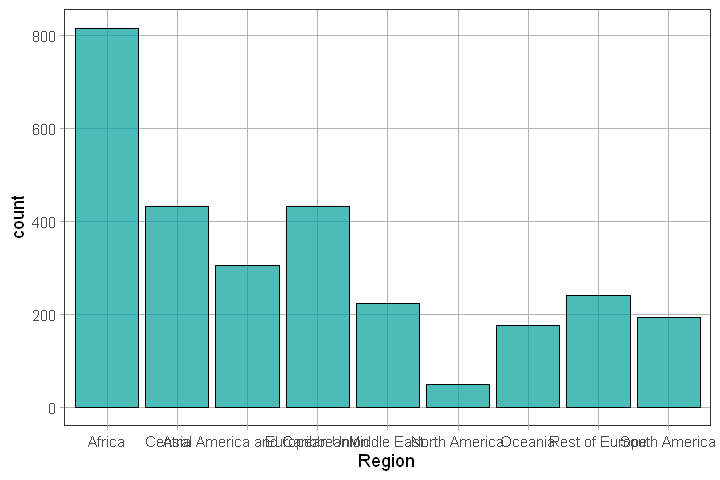

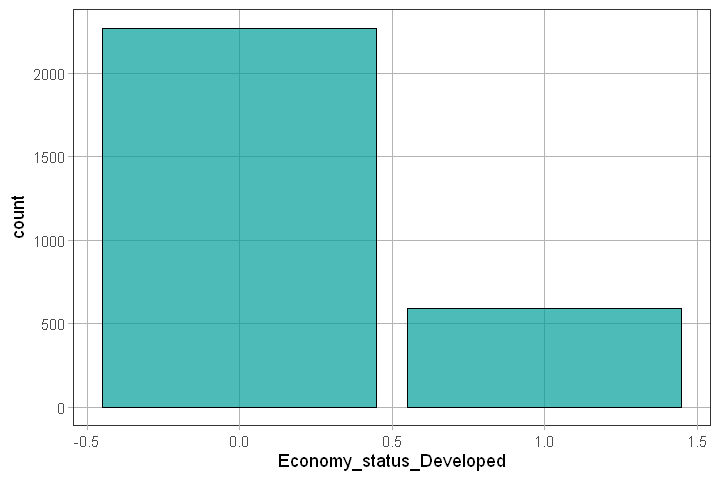

In [3]:
gf_bar(~ Region, data = life_exp_data)
gf_bar(~ Economy_status_Developed, data = life_exp_data)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


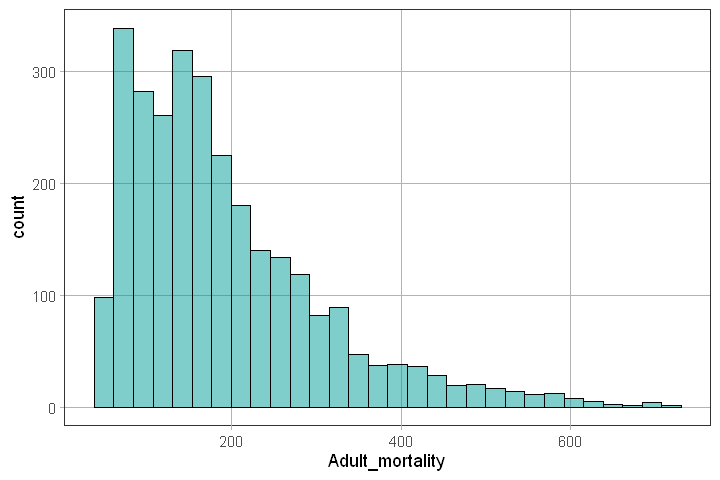

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


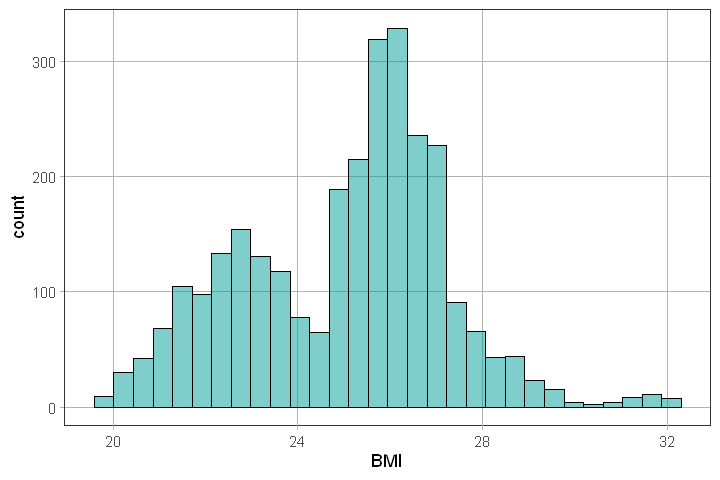

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


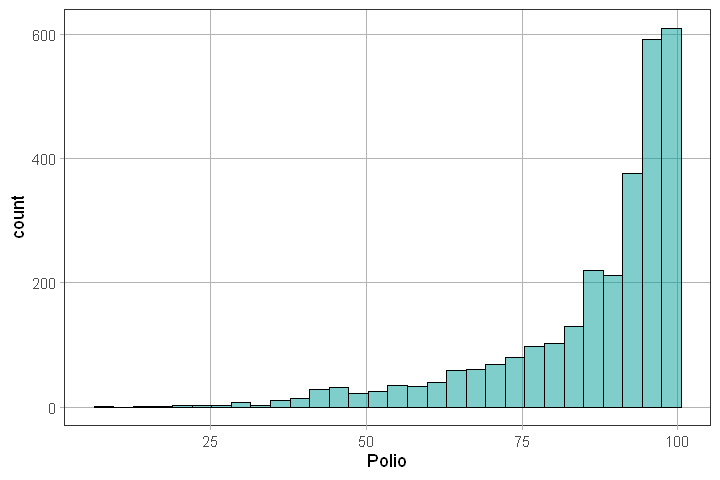

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


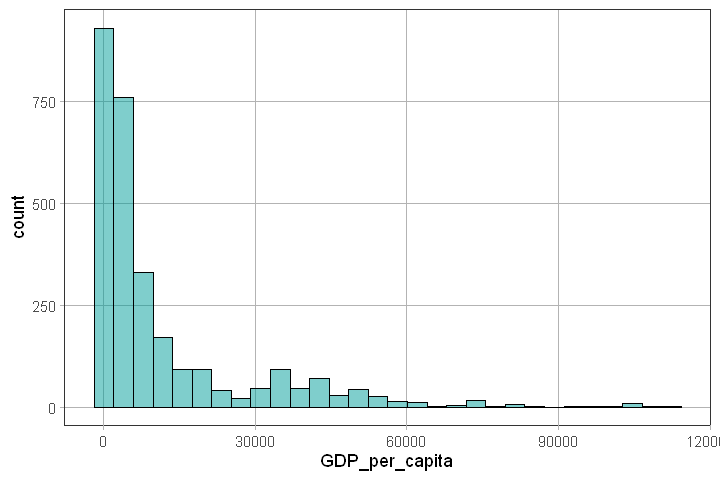

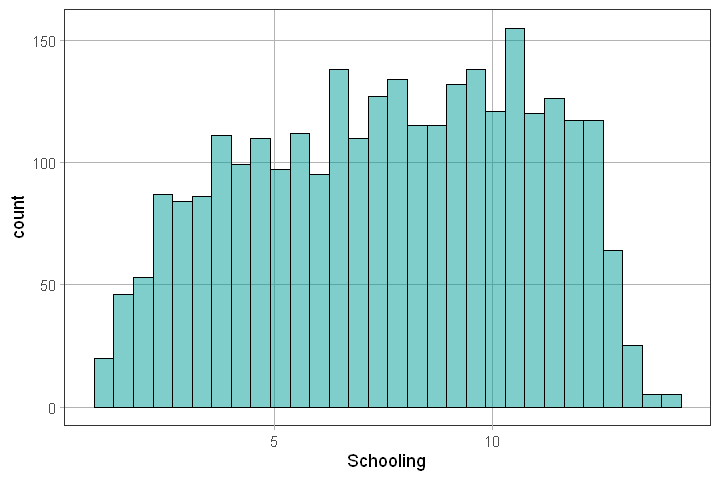

In [4]:
gf_histogram(~ Adult_mortality, data = life_exp_data)
gf_histogram(~ BMI, data = life_exp_data)
gf_histogram(~ Polio, data = life_exp_data)
gf_histogram(~ GDP_per_capita, data = life_exp_data)
gf_histogram(~ Schooling, data = life_exp_data)

Most of the histograms are skewed, especially GDP

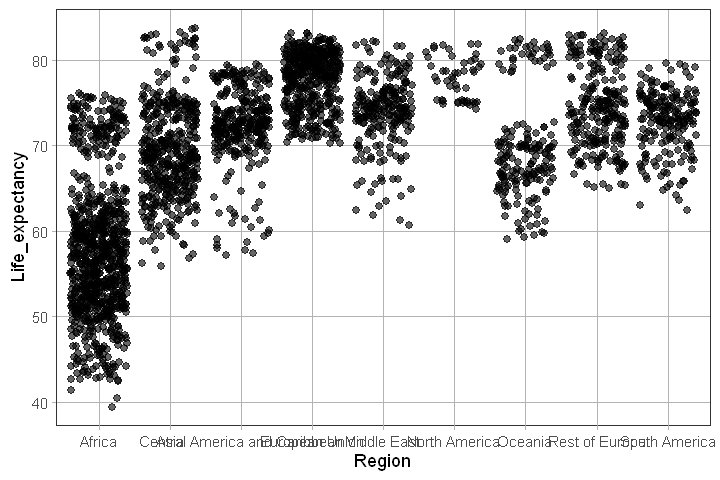

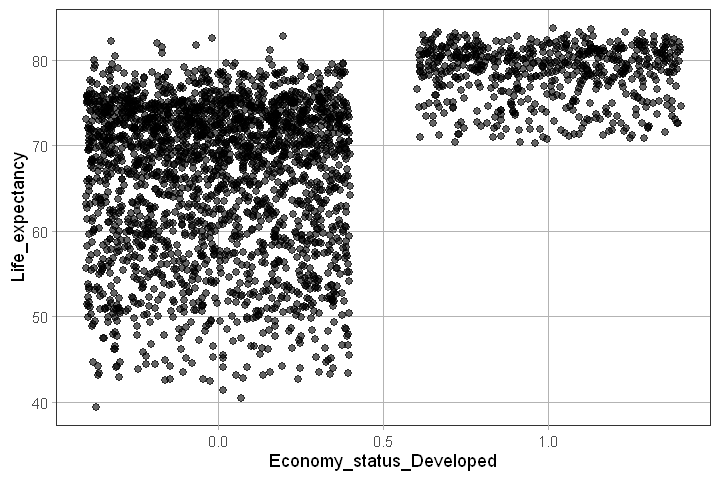

In [5]:
gf_jitter(Life_expectancy ~ Region, data = life_exp_data)
gf_jitter(Life_expectancy ~ Economy_status_Developed, data = life_exp_data)

The region with the lowest life expectancy was Africa. In general, developing countries had lower life expectancies than developed, and varied a lot more.

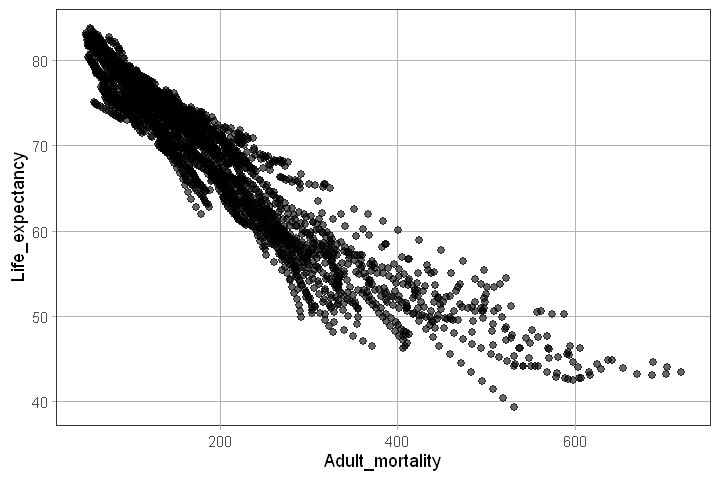

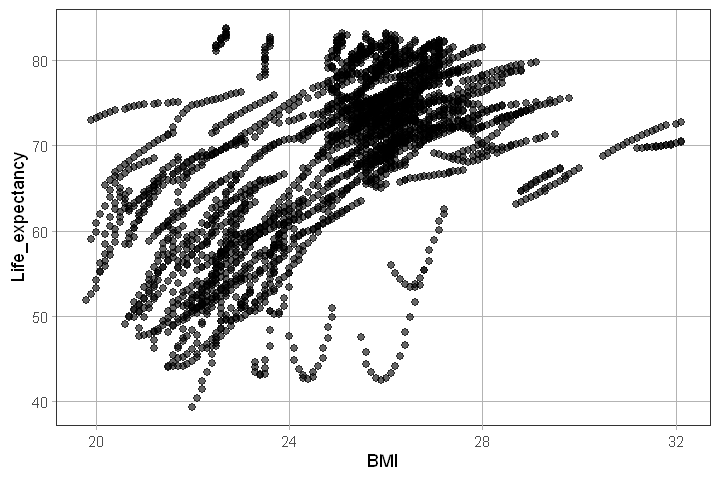

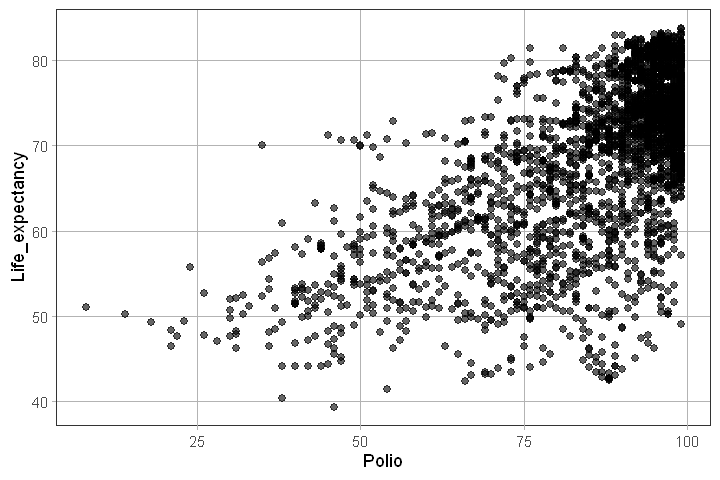

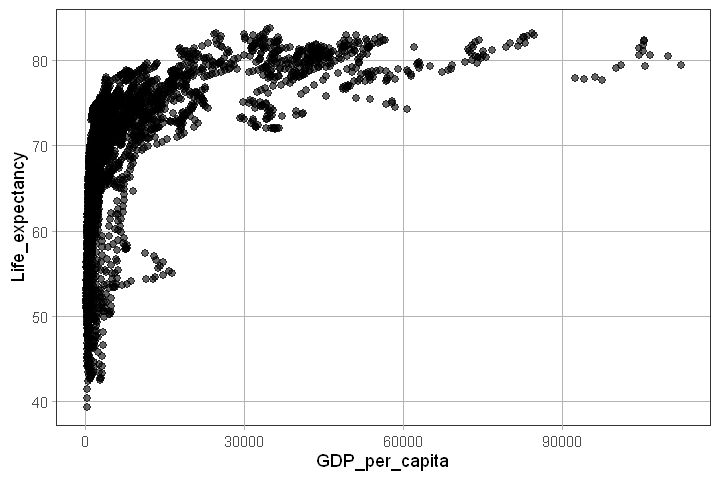

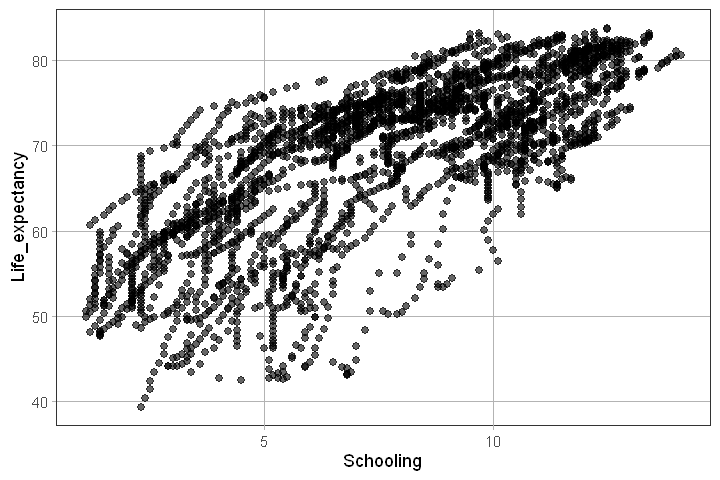

In [6]:
gf_point(Life_expectancy ~ Adult_mortality, data = life_exp_data)
gf_point(Life_expectancy ~ BMI, data = life_exp_data)
gf_point(Life_expectancy ~ Polio, data = life_exp_data)
gf_point(Life_expectancy ~ GDP_per_capita, data = life_exp_data)
gf_point(Life_expectancy ~ Schooling, data = life_exp_data)

Adult mortality has a strong, linear, and negative relation with life expectancy. BMI, Polio, and Schooling have less strong relations with life expectancy, but are positive and linear. GDP per capita also had a strong positive relation, but is curved.

## Part 2: Data Processing & Baseline Model
We will now prepare our data for modeling and fit a baseline model. Our baseline model's accuracy will be used as a comparison point for more advanced models. In this section, we will:
- One-hot encode our categorical predictors. (**Note: not applicable to this dataset. We'll skip this step.**)
- Split our data into train and test sets .
- Fit a baseline model to predict `Life_expectancy`. This model will simply be the mean of `Life_expectancy` in the train data (i.e. the mean model).
- Test the prediction accuracy of our baseline model by calculating its RMSE on the test set.

Let's start by splitting our dataset into an 80/20 train and test split.

In [7]:
set.seed(123)

N = nrow(life_exp_data)
train_size = round(0.8 * N)
train_rows <- sample.int(n = N, size = train_size, replace = F)

train <- life_exp_data[train_rows, ]
test  <- life_exp_data[-train_rows, ]

dim(train)
dim(test)

[1] 2291   21

[1] 573  21

In [8]:
mean_model = mean(train$Life_expectancy)
mean_model

[1] 68.98341

In [9]:
errors_mean = test$Life_expectancy - mean_model

rmse_mean = sqrt(mean(errors_mean^2))
rmse_mean

[1] 9.782149

The baseline is about 9.78 years, and this is the floor. This means that a model which doesn't get lower than that did not learn anything. It ignored predictors and guesses the training mean for every country.

## Part 3: Advanced Models - Regression
In this section, we will:
- Train different multiple regression models on the train set.
- Test (on the test set) the prediction accuracy from our models, using RMSE.
- Interpret the coefficients from the most accurate multiple regression model, to see which factors appear to be most important for predicting `Life_expectancy`.

In [10]:
regression_model = lm(Life_expectancy ~ Region + Infant_deaths + GDP_per_capita + Schooling, data = train)

regression_errors = test$Life_expectancy - predict(regression_model, newdata = test)

regression_rmse = sqrt(mean(regression_errors^2))
regression_rmse

[1] 2.904768

In [11]:
life_exp_data_numeric = life_exp_data[, !names(life_exp_data) %in% c("Region", "Year", "Country","Economy_status_Developed","Economy_status_Developing")]
life_exp_data_numeric = life_exp_data_numeric %>% 
    select(Life_expectancy, everything())
cor_table = round(cor(life_exp_data_numeric, method = "pearson"),2)

cor_table[upper.tri(cor_table)] <- " "
cor_table

,Life_expectancy,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling
Life_expectancy,1,,,,,,,,,,,,,,,
Infant_deaths,-0.92,1,,,,,,,,,,,,,,
Under_five_deaths,-0.92,0.99,1,,,,,,,,,,,,,
Adult_mortality,-0.95,0.79,0.8,1,,,,,,,,,,,,
Alcohol_consumption,0.4,-0.45,-0.41,-0.24,1,,,,,,,,,,,
Hepatitis_B,0.42,-0.51,-0.51,-0.34,0.17,1,,,,,,,,,,
Measles,0.49,-0.53,-0.51,-0.42,0.32,0.43,1,,,,,,,,,
BMI,0.6,-0.66,-0.67,-0.52,0.28,0.35,0.42,1,,,,,,,,
Polio,0.64,-0.74,-0.74,-0.52,0.3,0.72,0.51,0.46,1,,,,,,,
Diphtheria,0.63,-0.72,-0.73,-0.51,0.3,0.76,0.49,0.43,0.95,1,,,,,,


In [12]:
poly_degrees = sapply(1:10, function(d) {
  m <- lm(Life_expectancy ~ Adult_mortality + BMI + Polio + poly(GDP_per_capita, d) + Schooling, data = train)
  sqrt(mean((test$Life_expectancy - predict(m, newdata = test))^2))
})
poly_degrees

[1] 2.010503 1.986044 1.971044 1.960390 1.942168 1.933128 1.922212 1.920578
 [9] 1.923369 1.915715


Call:
lm(formula = Life_expectancy ~ log(GDP_per_capita), data = life_exp_data)

Coefficients:
        (Intercept)  log(GDP_per_capita)  
             25.338                5.181  


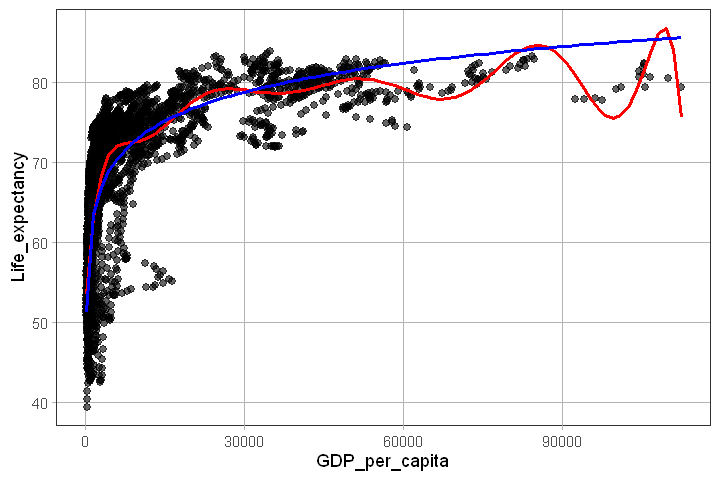

In [13]:
gdp_viz_model = lm(Life_expectancy ~ log(GDP_per_capita), data = life_exp_data)
gdp_viz_model

gf_point(Life_expectancy ~ GDP_per_capita, data = life_exp_data) %>%
  gf_smooth(method = "lm", formula = y ~ poly(x, 10), color = "red") %>%
  gf_smooth(method = "lm", formula = y ~ log(x), color = "blue")

In [14]:
regression_log_model = lm(Life_expectancy ~ Adult_mortality + BMI + Polio + log(GDP_per_capita) + Schooling, data = train)

regression_log_errors = test$Life_expectancy - predict(regression_log_model, newdata = test)
regression_log_rmse = sqrt(mean(regression_log_errors^2))
regression_log_rmse

summary(regression_log_model)

[1] 1.926258


Call:
lm(formula = Life_expectancy ~ Adult_mortality + BMI + Polio + 
    log(GDP_per_capita) + Schooling, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.7076 -1.0860 -0.0004  1.1927  6.9904 

Coefficients:
                      Estimate Std. Error  t value Pr(>|t|)    
(Intercept)         63.1952142  0.6541636   96.605  < 2e-16 ***
Adult_mortality     -0.0570313  0.0004728 -120.626  < 2e-16 ***
BMI                 -0.0763599  0.0239620   -3.187  0.00146 ** 
Polio                0.0771641  0.0033204   23.239  < 2e-16 ***
log(GDP_per_capita)  0.9971507  0.0477012   20.904  < 2e-16 ***
Schooling            0.4573694  0.0207638   22.027  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.85 on 2285 degrees of freedom
Multiple R-squared:  0.9606,	Adjusted R-squared:  0.9605 
F-statistic: 1.114e+04 on 5 and 2285 DF,  p-value: < 2.2e-16


We used a correlation table to determine whether two predictor variables seemed too similar to each other or not, and we got that the mortality rates for children 1 and 5 along with adults were all very similar. Because of that, we chose to use adults only for our regression models. We did this for some other variables and chose the variables BMI, Polio, GDP per capita, and Schooling for our predictor variables. We also noticed that GDP per capita was curved before, so we decided to run it with polynomials from degrees 1 to 10, finding 10 to be the lowest. We did see, however, that in the region above 60000 GDP per capita that the polynomial was oscillating, suggesting polynomial geometry rather than a real pattern. Instead, we used a log model, and this cost us about 0.01 years of RMSE, but it gave us a more defensible model. One thing, the degree was chosen on the test set, which is a mild leak.

## Part 4: Advanced Models - Neural Networks
In this section, we will:
- Scale all quantitative predictors to vary between 0 - 1.
- Fit several neural network models on the train data.
- Test (on the test set) the prediction accuracy of our models, using the RMSE on the test set.
- Compare the RMSE of our best neural network with the RMSE of our best regression model.

Let's load our neural network package:


In [15]:
if (!requireNamespace("neuralnet", quietly = TRUE)) install.packages("neuralnet")
library(neuralnet)


Attaching package: 'neuralnet'


The following object is masked from 'package:dplyr':

    compute




Now, let's scale our data. Make all our quantitative predictors vary between 0 - 1 by dividing each by their maxima. We also scaled the target to a 0 - 1 range because with predictors in the 0 - 1 range and the life expectancy being near 70, the network can't reach the target range and settles on predicting the training mean, and stops. Note that we are storing these scaled values in new dataframes called `train_net` and `test_net`. We'll use the new dataframes for training and testing our neural networks.

In [16]:
train_net <- train
train_net$Life_expectancy <- train$Life_expectancy / max(life_exp_data$Life_expectancy)
train_net$Infant_deaths <- train$Infant_deaths / max(life_exp_data$Infant_deaths)
train_net$Under_five_deaths <- train$Under_five_deaths / max(life_exp_data$Under_five_deaths)
train_net$Adult_mortality <- train$Adult_mortality / max(life_exp_data$Adult_mortality)
train_net$Alcohol_consumption<- train$Alcohol_consumption / max(life_exp_data$Alcohol_consumption)
train_net$Hepatitis_B <- train$Hepatitis_B / max(life_exp_data$Hepatitis_B)
train_net$Measles <- train$Measles / max(life_exp_data$Measles)
train_net$BMI <- train$BMI / max(life_exp_data$BMI)
train_net$Incidents_HIV <- train$Incidents_HIV / max(life_exp_data$Incidents_HIV)
train_net$Diphtheria <- train$Diphtheria / max(life_exp_data$Diphtheria)
train_net$Polio <- train$Polio / max(life_exp_data$Polio)
train_net$GDP_per_capita <- train$GDP_per_capita / max(life_exp_data$GDP_per_capita)
train_net$Population_mln <- train$Population_mln / max(life_exp_data$Population_mln)
train_net$Thinness_ten_nineteen_years<- train$Thinness_ten_nineteen_years / max(life_exp_data$Thinness_ten_nineteen_years)
train_net$Thinness_five_nine_years <- train$Thinness_five_nine_years / max(life_exp_data$Thinness_five_nine_years)
train_net$Schooling <- train$Schooling / max(life_exp_data$Schooling)

test_net <- test
test_net$Life_expectancy <- test$Life_expectancy / max(life_exp_data$Life_expectancy)
test_net$Infant_deaths <- test$Infant_deaths / max(life_exp_data$Infant_deaths)
test_net$Under_five_deaths <- test$Under_five_deaths / max(life_exp_data$Under_five_deaths)
test_net$Adult_mortality <- test$Adult_mortality / max(life_exp_data$Adult_mortality)
test_net$Alcohol_consumption<- test$Alcohol_consumption / max(life_exp_data$Alcohol_consumption)
test_net$Hepatitis_B <- test$Hepatitis_B / max(life_exp_data$Hepatitis_B)
test_net$Measles <- test$Measles / max(life_exp_data$Measles)
test_net$BMI <- test$BMI / max(life_exp_data$BMI)
test_net$Incidents_HIV <- test$Incidents_HIV / max(life_exp_data$Incidents_HIV)
test_net$Diphtheria <- test$Diphtheria / max(life_exp_data$Diphtheria)
test_net$Polio <- test$Polio / max(life_exp_data$Polio)
test_net$GDP_per_capita <- test$GDP_per_capita / max(life_exp_data$GDP_per_capita)
test_net$Population_mln <- test$Population_mln / max(life_exp_data$Population_mln)
test_net$Thinness_ten_nineteen_years<- test$Thinness_ten_nineteen_years / max(life_exp_data$Thinness_ten_nineteen_years)
test_net$Thinness_five_nine_years <- test$Thinness_five_nine_years / max(life_exp_data$Thinness_five_nine_years)
test_net$Schooling <- test$Schooling / max(life_exp_data$Schooling)

head(train_net)
head(test_net)

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,⋯,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
2463,Australia,Oceania,2004,0.03475742,0.02578924,0.09441719,0.5506435,0.9595960,0.8585859,0.8286604,⋯,0.9292929,0.002306273,0.43977833,0.0145884365,0.02527076,0.02097902,0.8368794,1,0,0.9606205
2511,Senegal,Africa,2007,0.34902245,0.35304580,0.31833900,0.0190263,0.9494949,0.3333333,0.7040498,⋯,0.9494949,0.016605166,0.01006956,0.0084718740,0.39711191,0.06643357,0.1702128,0,1,0.7410501
2227,"Bahamas, The",Central America and Caribbean,2003,0.10354815,0.07425522,0.25420356,0.5926133,0.8888889,0.8383838,0.8411215,⋯,0.9292929,0.034594096,0.31539433,0.0002246605,0.09386282,0.08741259,0.7730496,0,1,0.8591885
526,Belgium,European Union,2014,0.02389573,0.01823032,0.10061576,0.5914941,0.9898990,0.8585859,0.8130841,⋯,1.0000000,0.003690037,0.35955986,0.0081240126,0.03610108,0.03496503,0.8156028,1,0,0.9701671
195,Japan,Asia,2004,0.02027516,0.01734104,0.09581913,0.4303302,0.8383838,0.8787879,0.7040498,⋯,1.0000000,0.007841328,0.28923304,0.0925891032,0.06137184,0.04895105,0.7872340,1,0,0.9785203
1842,Luxembourg,European Union,2007,0.01810282,0.01378390,0.10858603,0.6866256,0.8787879,0.8686869,0.8099688,⋯,1.0000000,0.004151292,1.00000000,0.0003478614,0.03249097,0.03146853,0.8297872,1,0,0.9474940


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,⋯,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
3,India,Asia,2007,0.37291818,0.30191196,0.27952119,0.08785674,0.6060606,0.3535354,0.6604361,⋯,0.6464646,0.0059963100,0.009571421,8.574855e-01,0.978339350,0.979020979,0.3546099,0,1,0.7804296
6,Costa Rica,Central America and Caribbean,2006,0.07096307,0.04979991,0.13236757,0.23447118,0.8888889,0.8686869,0.8224299,⋯,0.8989899,0.0073800738,0.081036845,3.152494e-03,0.072202166,0.066433566,0.5602837,0,1,0.9331742
15,Switzerland,Rest of Europe,2006,0.03041274,0.02178746,0.08791628,0.57302742,0.8888889,0.7171717,0.7788162,⋯,0.9494949,0.0036900369,0.706007935,5.420840e-03,0.021660650,0.013986014,0.8723404,1,0,0.9725537
22,Philippines,Asia,2001,0.20419986,0.16407292,0.29785970,0.25349748,0.4545455,0.1919192,0.6947040,⋯,0.7979798,0.0004612546,0.016429753,5.773774e-02,0.036101083,0.339160839,0.5460993,0,1,0.8210024
28,Cameroon,Africa,2015,0.41274439,0.39128502,0.47281787,0.25461668,0.8484848,0.6464646,0.7570093,⋯,0.8484848,0.0516605166,0.012302300,1.688577e-02,0.202166065,0.192307692,0.4326241,0,1,0.6873508
38,Kiribati,Oceania,2004,0.35771180,0.28723877,0.29856310,0.02742026,0.6767677,0.3434343,0.9065421,⋯,0.6262626,0.0078413284,0.013236314,6.522401e-05,0.007220217,0.006993007,0.5106383,0,1,0.7661098


Now that we've scaled our data we are ready to start modeling.

In [17]:
train_net_select = select(train_net, c("Life_expectancy", "Adult_mortality", "BMI", "Polio", "GDP_per_capita", "Schooling"))
head(train_net_select)

,Life_expectancy,Adult_mortality,BMI,Polio,GDP_per_capita,Schooling
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2463,0.9606205,0.09441719,0.8286604,0.9292929,0.43977833,0.8368794
2511,0.7410501,0.31833900,0.7040498,0.9393939,0.01006956,0.1702128
2227,0.8591885,0.25420356,0.8411215,0.9393939,0.31539433,0.7730496
526,0.9701671,0.10061576,0.8130841,1.0000000,0.35955986,0.8156028
195,0.9785203,0.09581913,0.7040498,0.9797980,0.28923304,0.7872340
1842,0.9474940,0.10858603,0.8099688,0.9696970,1.00000000,0.8297872


In [18]:
neural_model_1 = neuralnet(
    Life_expectancy ~ Adult_mortality + BMI + Polio + GDP_per_capita + Schooling,
    data = train_net_select,
    lifesign = 'full',
    threshold = 0.01,
    rep = 5,
    hidden = c(8,4,2)
)


hidden: 8, 4, 2    thresh: 0.01    rep: 1/5    steps: 
    752
	error: 0.42151
	time: 5.6 secs

hidden: 8, 4, 2    thresh: 0.01    rep: 2/5    steps: 
   1000	min thresh: 0.0214939255477738
                                                      
   1913
	error: 0.38138
	time: 13.73 secs

hidden: 8, 4, 2    thresh: 0.01    rep: 3/5    steps: 
    935
	error: 0.41859
	time: 6.61 secs

hidden: 8, 4, 2    thresh: 0.01    rep: 4/5    steps: 
   1000	min thresh: 0.0278595284851584
                                                      
   2000	min thresh: 0.0143396671723363
                                                      
   2077
	error: 0.38609
	time: 15.02 secs

hidden: 8, 4, 2    thresh: 0.01    rep: 5/5    steps: 
   1000	min thresh: 0.0164042704483389
                                                      
   2000	min thresh: 0.0139591321317047
                                                      
   2055
	error: 0.36153
	time: 14.78 secs



In [19]:
y_max = max(life_exp_data$Life_expectancy)

rmse_neural_1 <- sapply(1:5, function(r) {
    p <- as.vector(predict(neural_model_1, newdata = test_net, rep = r)) * y_max
    sqrt(mean((test$Life_expectancy - p)^2))
})

rmse_neural_1
mean(rmse_neural_1)

[1] 1.724242 1.636455 1.712747 1.627889 1.608048

[1] 1.661876

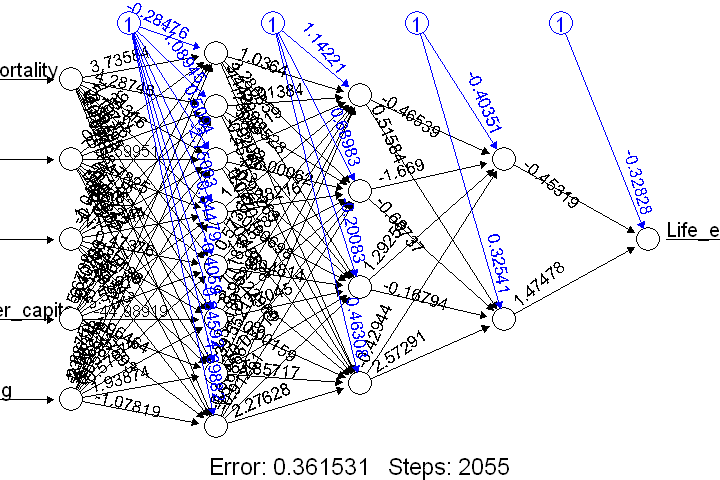

In [20]:
plot(neural_model_1, rep = 'best')

In [21]:
neural_model_2 = neuralnet(
    Life_expectancy ~ Adult_mortality + BMI + Polio + GDP_per_capita + Schooling,
    data = train_net_select,
    lifesign = 'full',
    threshold = 0.01,
    rep = 5,
    hidden = c(32,16,8,4,2)
)


hidden: 32, 16, 8, 4, 2    thresh: 0.01    rep: 1/5    steps: 
   1000	min thresh: 0.0107717134171538
                                                              
   1065
	error: 0.31201
	time: 35.52 secs

hidden: 32, 16, 8, 4, 2    thresh: 0.01    rep: 2/5    steps: 
    612
	error: 0.34252
	time: 20.4 secs

hidden: 32, 16, 8, 4, 2    thresh: 0.01    rep: 3/5    steps: 
   1000	min thresh: 0.0101321253272995
                                                              
   1911
	error: 0.24618
	time: 1.06 mins

hidden: 32, 16, 8, 4, 2    thresh: 0.01    rep: 4/5    steps: 
    642
	error: 0.34755
	time: 21.08 secs

hidden: 32, 16, 8, 4, 2    thresh: 0.01    rep: 5/5    steps: 
   1000	min thresh: 0.0136584124791592
                                                              
   1347
	error: 0.2992 
	time: 44.64 secs



In [22]:
rmse_neural_2 <- sapply(1:5, function(r) {
    p <- as.vector(predict(neural_model_2, newdata = test_net, rep = r)) * y_max
    sqrt(mean((test$Life_expectancy - p)^2))
})

rmse_neural_2
mean(rmse_neural_2)

[1] 1.492674 1.600791 1.406438 1.600611 1.507703

[1] 1.521643

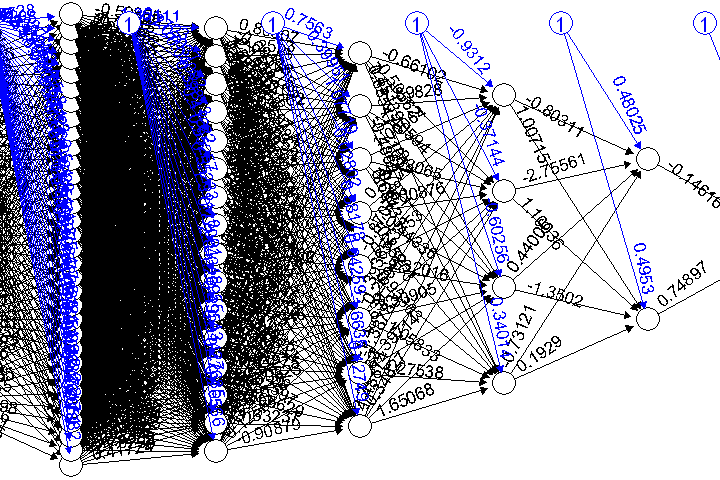

In [23]:
plot(neural_model_2, rep = 'best')

Both neural architectures previously returned 9.78, nearly identical to each other and the mean, suggesting that the architecture did not matter. The predictions also had a standard deviation of exactly 0, every country's life expectancy got 68.98, exactly the training mean. This is because the target variable life_expectancy was not scaled. After scaling, we ran 5 reps on each model one being 8-4-2 averaging an RMSE of 1.662 and having a range of 1.608 - 1.724, and the 32-16-8-4-2 averaging an RMSE of 1.522 ranging from 1.406 - 1.601. The gap between the two survives multiple trials. A thing to note is that several reps hit the step limit without converging.

## Part 5: Evaluation & Conclusion
In this section, we will...
- Print out the **actual** `Life_expectancy` for 2015 in our dataset, arranging them in order.
- Use our best model to predict `Life_expectancy` for 2015, in order to generate our **predicted** standings.
- Compare our model's predicted life expectancy to the actual life expectancy, to determine whether our model is a reasonably reliable predictor.
- Answer the project's original question: Can AI predict life expectancy? In other words, what key factors should we consider if we want to live a longer life?  We'll answer this question based on the coefficients from our best regression model.
- Discuss limitations and further work that could be done to improve our model.

First, let's filter our dataset for life expectancy in 2015 and print out the results (countries arranged by their life expectancy in descending order)

In [24]:
life_exp_2015 <- filter(test, Year == 2015)
net_2015 <- test_net[test$Year == 2015, ]

head(arrange(life_exp_2015, desc(Life_expectancy)))

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,⋯,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
1,Singapore,Asia,2015,2.2,2.7,50.9615,1.82,96,90,23.6,⋯,96,0.07,55647,5.54,2.2,2.2,11.5,0,1,82.7
2,Italy,European Union,2015,3.0,3.5,52.9595,7.14,93,83,25.6,⋯,93,0.06,30242,60.73,0.6,0.6,10.2,1,0,82.5
3,Norway,Rest of Europe,2015,2.2,2.7,53.8970,5.97,88,91,26.6,⋯,95,0.04,74356,5.19,0.8,0.7,12.5,1,0,82.3
4,Sweden,European Union,2015,2.3,2.9,53.4415,7.13,67,95,26.0,⋯,98,0.08,51545,9.80,1.5,1.4,12.4,1,0,82.2
5,New Zealand,Oceania,2015,4.6,5.5,67.0000,8.68,92,87,28.0,⋯,92,0.03,38631,4.61,0.4,0.3,12.4,1,0,81.5
6,Portugal,European Union,2015,3.0,3.6,73.2830,10.34,98,95,25.7,⋯,98,0.12,19250,10.36,0.7,0.5,9.1,1,0,81.1


We will now use our models to predict life expectancy per country for 2015. We'll add our predictions as a column in our dataset and arrange the data based on that column to get our predicted life expectancy.

In [25]:
regression_2015 <- predict(regression_log_model, newdata = life_exp_2015)

network_2015 <- as.vector(predict(neural_model_2, newdata = net_2015, rep = 3)) * y_max

life_exp_2015$pred_regression <- regression_2015
life_exp_2015$pred_network <- network_2015

life_exp_2015 <- life_exp_2015 %>%
  select(Country, pred_regression, pred_network, Life_expectancy, everything())

head(arrange(life_exp_2015, desc(pred_network)))

,Country,pred_regression,pred_network,Life_expectancy,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,⋯,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,Singapore,82.04987,82.32015,82.7,Asia,2015,2.2,2.7,50.9615,1.82,⋯,96,96,0.07,55647,5.54,2.2,2.2,11.5,0,1
2,Norway,82.32259,82.14006,82.3,Rest of Europe,2015,2.2,2.7,53.8970,5.97,⋯,95,95,0.04,74356,5.19,0.8,0.7,12.5,1,0
3,Sweden,82.21478,82.11517,82.2,European Union,2015,2.3,2.9,53.4415,7.13,⋯,98,98,0.08,51545,9.80,1.5,1.4,12.4,1,0
4,Italy,80.34907,81.65091,82.5,European Union,2015,3.0,3.5,52.9595,7.14,⋯,93,93,0.06,30242,60.73,0.6,0.6,10.2,1,0
5,New Zealand,80.53824,80.89123,81.5,Oceania,2015,4.6,5.5,67.0000,8.68,⋯,92,92,0.03,38631,4.61,0.4,0.3,12.4,1,0
6,Bahrain,79.31267,80.13512,76.8,Middle East,2015,6.5,7.6,66.6840,1.53,⋯,98,98,0.05,22634,1.37,6.2,6.1,9.3,0,1


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


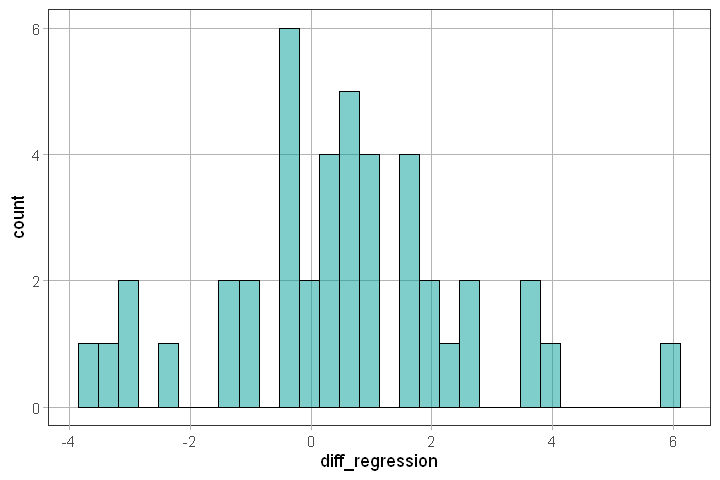

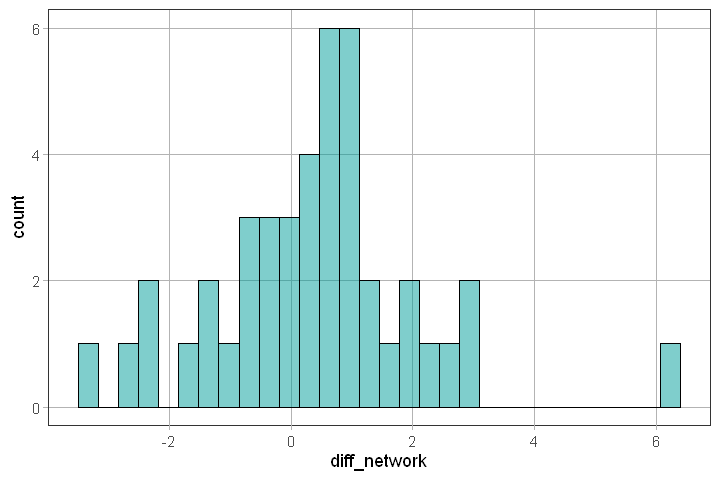

In [28]:
life_exp_2015$diff_regression <- life_exp_2015$Life_expectancy - life_exp_2015$pred_regression
life_exp_2015$diff_network    <- life_exp_2015$Life_expectancy - life_exp_2015$pred_network

gf_histogram(~diff_regression, data = life_exp_2015)
gf_histogram(~diff_network, data = life_exp_2015)

In [29]:
sqrt(mean(life_exp_2015$diff_regression^2))
sqrt(mean(life_exp_2015$diff_network^2))

mean(life_exp_2015$diff_regression)
mean(life_exp_2015$diff_network)

life_exp_2015 %>%
  arrange(desc(diff_network)) %>%
  select(Country, Life_expectancy, pred_network, pred_regression) %>%
  head(5)

[1] 2.016876

[1] 1.716465

[1] 0.4730907

[1] 0.3841485

,Country,Life_expectancy,pred_network,pred_regression
,<chr>,<dbl>,<dbl>,<dbl>
1,Syrian Arab Republic,69.9,63.66243,63.94192
2,Honduras,74.5,71.57356,70.96319
3,Malawi,62.0,59.13925,59.36680
4,Somalia,55.9,53.32669,54.37443
5,Thailand,76.1,73.97139,72.61136


We are able to answer the original question, yes, AI can predict life expectancy. Starting with a baseline RMSE of 9.78 using the mean, we were able to get an RMSE of 1.522 using a neural network.

The neural models beat the regression, as they had RMSE's of 1.662 and 1.522, lower than the regression of 1.926 (and the degree 10 polynomial, whose curve oscillates where data is spase with an RMSE of 1.916). The regression stays for interpretation.

The main key factors which impact a longer life would be Adult Mortality, BMI, Polio, GDP per capita, and Schooling. As adult mortality increases, life expectancy decreases linearly. As the rest except BMI increase, so does life expectancy, linearly for all but GDP per capita. BMI in the first scatterplot seems as though it increases with life expectancy, but when GDP per capita and schooling are controlled for, the remaining BMI actually negatively affects life expectancy. This can be seen as the BMI has a p of 0.0015, meaning it was significant, and for one unit increase in BMI, life expectancy decreased by 0.0764 years. Because GDP per capita was transformed by log, its coefficient of 0.997 means that doubling the GDP per capita is associated with roughly 0.7 additional years of life expectancy. This decreasing return matches what we see in the scatterplot, where increasing the GDP at low income levels increase life expectancy a lot more than increasing at high GDP's.

The model under-predicted 2015 by 0.38 years on average. Its largest errors were in countries under stress, for example, the model was off by 6.2 years for Syria. It was predicted at 63.7 but was actually 69.9. Honduras, Malawi, Somalia and Thailand were also not predicted well by the model. In conflict and crisis states, the health and economic indicators the model relies on deteriorate faster than realized life expectancy does, so the model reads catastrophic inputs and predicts too low. The model is least reliable exactly where conditions are most extreme, underpredicting the life expectancy by the most.

Some limitations include the train/test split being random across all rows, ignoring the data's time structure. Since life expectancy rose over 2000 – 2015, that likely explains why 2015 was under predicted by 0.38 years. Additionally, the polynomial degree was chosen by test set RMSE instead of the training set, which means there was a slight leak, the model got information about the test set it should not have had. Finally, the neural network scaling uses the full dataset maxima rather than training maxima, which leaks a small amount of test information, and several reps hit the step limit without converging, so the architecture comparison is between partially trained models.

Future work includes a time based split to account for life expectancy increasing as time passes, validation set for tuning, and converging networks.